# LangGraph Multi-Agent Workshop

---
# Part 0 — Setup

In [2]:
!pip install langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.4 MB/s eta 0:00:00


In [4]:
import os, json, time, copy, textwrap, operator, re
from datetime import datetime
from typing import TypedDict, Annotated, Literal, Any
from dataclasses import dataclass, field, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown, HTML

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, BaseMessage
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent, ToolNode

sns.set_theme(style='darkgrid')
print('All imports successful')

All imports successful


In [5]:
from google.colab import userdata

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

if not GEMINI_API_KEY:
    GEMINI_API_KEY = input('Enter your Gemini API key: ').strip()

llm = ChatGoogleGenerativeAI(
    model='gemini-2.0-flash',
    google_api_key=GEMINI_API_KEY,
    temperature=0.7,
)

# Quick sanity check
resp = llm.invoke('Reply with exactly: LANGGRAPH READY')
print(f'Model check: {resp.content}')

# Utility: call with temperature override
def get_llm(temperature=0.7):
    return ChatGoogleGenerativeAI(
        model='gemini-2.0-flash',
        google_api_key=GEMINI_API_KEY,
        temperature=temperature,
    )

Model check: LANGGRAPH READY


---
# Part 1 — LangGraph Fundamentals

LangGraph models agent workflows as **directed graphs**:
- **Nodes** = functions (agents, tools, checks)
- **Edges** = control flow (including conditional + cyclic)
- **State** = typed dict that flows through the graph

Key features: **checkpointing**, **scratchpad** (working memory), **human-in-the-loop**.

In [6]:
# Basic StateGraph
# Simplest possible graph: two nodes, linear flow.

class SimpleState(TypedDict):
    messages: Annotated[list[str], operator.add]  # append-only list
    step: str

def node_greet(state: SimpleState) -> dict:
    return {'messages': ['Hello from Node A!'], 'step': 'greeted'}

def node_process(state: SimpleState) -> dict:
    return {'messages': ['Processed by Node B!'], 'step': 'done'}

# Build the graph
g = StateGraph(SimpleState)
g.add_node('greet', node_greet)
g.add_node('process', node_process)
g.add_edge(START, 'greet')
g.add_edge('greet', 'process')
g.add_edge('process', END)

app = g.compile()
result = app.invoke({'messages': [], 'step': 'init'})

print('Graph result:')
for m in result['messages']:
    print(f'  -> {m}')
print(f'Final step: {result["step"]}')

Graph result:
  -> Hello from Node A!
  -> Processed by Node B!
Final step: done


In [8]:
# Checkpointing — Persist and Resume State
# MemorySaver stores graph state so we can resume, replay, or branch.

checkpointer = MemorySaver()
app_ckpt = g.compile(checkpointer=checkpointer)

config = {'configurable': {'thread_id': 'session-001'}}
result1 = app_ckpt.invoke({'messages': [], 'step': 'init'}, config)
print(f'Run 1 messages: {result1["messages"]}')

# The state is now checkpointed — we can inspect it
snapshot = app_ckpt.get_state(config)
print(f'\nCheckpointed state: {snapshot.values}')
print(f'Next steps: {snapshot.next}')
print('\n Checkpointing works — state is persisted and resumable')

Run 1 messages: ['Hello from Node A!', 'Processed by Node B!']

Checkpointed state: {'messages': ['Hello from Node A!', 'Processed by Node B!'], 'step': 'done'}
Next steps: ()

 Checkpointing works — state is persisted and resumable


In [9]:
# Scratchpad Pattern — Agent Working Memory
# The scratchpad is a list of intermediate thoughts/observations that
# the agent accumulates as it works through a problem.

class ScratchpadState(TypedDict):
    task: str
    scratchpad: Annotated[list[str], operator.add]  # working memory
    answer: str

def think_node(state: ScratchpadState) -> dict:
    prompt = f"""Task: {state['task']}
Previous thoughts: {state['scratchpad'] or 'None yet'}

Write ONE brief thought about how to approach this. Just the thought, nothing else."""
    resp = llm.invoke(prompt)
    return {'scratchpad': [f'Thought: {resp.content.strip()}']}

def research_node(state: ScratchpadState) -> dict:
    prompt = f"""Task: {state['task']}
Your thoughts so far: {state['scratchpad']}

Write ONE key fact or observation. Just the fact, nothing else."""
    resp = llm.invoke(prompt)
    return {'scratchpad': [f'Observation: {resp.content.strip()}']}

def answer_node(state: ScratchpadState) -> dict:
    prompt = f"""Task: {state['task']}
Your working notes:\n{chr(10).join(state['scratchpad'])}

Now synthesize a final concise answer."""
    resp = llm.invoke(prompt)
    return {'answer': resp.content.strip()}

sg = StateGraph(ScratchpadState)
sg.add_node('think', think_node)
sg.add_node('research', research_node)
sg.add_node('answer', answer_node)
sg.add_edge(START, 'think')
sg.add_edge('think', 'research')
sg.add_edge('research', 'answer')
sg.add_edge('answer', END)

scratch_app = sg.compile()
result = scratch_app.invoke({'task': 'What are the pros and cons of microservices?', 'scratchpad': [], 'answer': ''})

print(' SCRATCHPAD:')
for note in result['scratchpad']:
    print(f'  {note}')
print(f'\n FINAL ANSWER:\n{result["answer"]}')

 SCRATCHPAD:
  Thought: Consider both technical and organizational aspects.
  Observation: Increased complexity in deployment and monitoring.

 FINAL ANSWER:
## Microservices: Pros and Cons

**Pros:**

*   **Increased Agility:** Smaller, independent services allow for faster development cycles, easier updates, and quicker deployment of new features.
*   **Technology Diversity:** Teams can choose the best technology for each specific service, leading to optimized performance and innovation.
*   **Scalability:** Individual services can be scaled independently based on demand, optimizing resource utilization and cost.
*   **Fault Isolation:** Failure in one service is less likely to cascade and bring down the entire application.
*   **Team Autonomy:** Enables smaller, more autonomous teams to own and manage their services independently.

**Cons:**

*   **Increased Complexity:** Distributed systems are inherently more complex to design, develop, and manage.
*   **Operational Overhead:** Re

In [10]:
# Human-in-the-Loop
# The graph pauses at a node, waits for human input, then continues.
# In LangGraph, this is done via interrupt_before / interrupt_after + update_state.

class HITLState(TypedDict):
    task: str
    draft: str
    human_feedback: str
    final: str

def draft_node(state: HITLState) -> dict:
    resp = llm.invoke(f'Write a brief 2-sentence draft for: {state["task"]}')
    return {'draft': resp.content.strip()}

def revise_node(state: HITLState) -> dict:
    if not state.get('human_feedback') or state['human_feedback'].lower() == 'approve':
        return {'final': state['draft']}
    resp = llm.invoke(
        f'Revise this draft:\n{state["draft"]}\n\nBased on feedback: {state["human_feedback"]}'
    )
    return {'final': resp.content.strip()}

hitl_graph = StateGraph(HITLState)
hitl_graph.add_node('draft', draft_node)
hitl_graph.add_node('revise', revise_node)
hitl_graph.add_edge(START, 'draft')
hitl_graph.add_edge('draft', 'revise')  # human review happens between these
hitl_graph.add_edge('revise', END)

hitl_checkpointer = MemorySaver()
# interrupt_before='revise' pauses the graph before the revise node
hitl_app = hitl_graph.compile(checkpointer=hitl_checkpointer, interrupt_before=['revise'])

config = {'configurable': {'thread_id': 'hitl-001'}}

# Step 1: Run until interrupt
result = hitl_app.invoke(
    {'task': 'Explain quantum computing in simple terms', 'draft': '', 'human_feedback': '', 'final': ''},
    config
)
snapshot = hitl_app.get_state(config)
print(f'DRAFT (awaiting human review):\n{snapshot.values["draft"]}')
print(f'\n Graph is PAUSED at: {snapshot.next}')

# Step 2: Inject human feedback and resume
human_input = 'Make it simpler, use an analogy with a library.'  # simulated human feedback
hitl_app.update_state(config, {'human_feedback': human_input})
print(f'\n Human feedback injected: "{human_input}"')

# Step 3: Resume
result = hitl_app.invoke(None, config)
print(f'\n FINAL OUTPUT:\n{result["final"]}')

DRAFT (awaiting human review):
Quantum computing uses the strange properties of quantum mechanics, like superposition and entanglement, to perform calculations that are impossible for regular computers. This allows it to tackle complex problems in fields like medicine, materials science, and artificial intelligence.

 Graph is PAUSED at: ('revise',)

 Human feedback injected: "Make it simpler, use an analogy with a library."

 FINAL OUTPUT:
Okay, here's a revised draft using the library analogy and simplifying the language:

**Revised Draft:**

Imagine a regular computer as a librarian who can only check one book at a time to find information. Quantum computers are like librarians who can check out *all* the books in the library *at once*. They use the special rules of quantum mechanics, like "superposition" and "entanglement," to do this. This lets them solve really complicated problems, like designing new medicines, discovering better materials, and improving artificial intelligence,

---
# Part 2 — Agentic Design Patterns

| Pattern | Idea | When to use |
|---------|------|-------------|
| **ReAct** | Reason → Act → Observe → loop | Tool-using agents |
| **Reflexion** | Generate → Evaluate → Reflect → Retry | Quality-critical tasks |
| **Plan-and-Execute** | Plan all steps → Execute sequentially | Complex multi-step tasks |
| **Multi-Agent Supervisor** | Boss routes tasks to specialist workers | Multi-domain problems |

In [15]:
# ── ReAct — Reason + Act ────────────────────────────────────────────────
# The agent thinks about what tool to call, calls it, observes the result, repeats.
# LangGraph has a prebuilt create_react_agent!

@tool
def calculate(expression: str) -> str:
    """Evaluate a math expression. Example: calculate('2 + 3 * 4')"""
    try:
        result = eval(expression, {'__builtins__': {}}, {})
        return f'Result: {result}'
    except Exception as e:
        return f'Error: {e}'

@tool
def lookup_fact(topic: str) -> str:
    """Look up a fact about a given topic."""
    facts = {
        'python': 'Python was created by Guido van Rossum in 1991.',
        'earth': 'Earth is ~4.5 billion years old and is the 3rd planet from the Sun.',
        'transformer': 'The Transformer architecture was introduced in "Attention Is All You Need" (2017).',
    }
    for key, val in facts.items():
        if key in topic.lower():
            return val
    return f'No fact found for: {topic}'

tools = [calculate, lookup_fact]

# create_react_agent builds the full ReAct loop: LLM → tool call → observation → loop
react_agent = create_react_agent(llm, tools)

print('ReAct Agent — Reason + Act pattern')
print('='*50)

result = react_agent.invoke(
    {'messages': [HumanMessage(content='What year was Python created, and what is 2026 minus that year?')]}
)

for msg in result['messages']:
    role = msg.__class__.__name__.replace('Message', '')
    content = msg.content if hasattr(msg, 'content') else str(msg)
    if content:
        print(f'\n[{role}]: {content[:300]}')

print('\n ReAct loop: Reason - Tool call - Observe - Reason - Final answer')

/tmp/ipykernel_872/3379921731.py:30: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  react_agent = create_react_agent(llm, tools)


ReAct Agent — Reason + Act pattern

[Human]: What year was Python created, and what is 2026 minus that year?

[Tool]: Python was created by Guido van Rossum in 1991.

[Tool]: Result: 35

[AI]: Python was created in 1991, and 2026 minus that year is 35.

 ReAct loop: Reason - Tool call - Observe - Reason - Final answer


In [17]:
# ── Reflexion Pattern ───────────────────────────────────────────────────
# Generate → Evaluate → Reflect on weakness → Regenerate improved version.
# The key insight: self-evaluation as an explicit graph node with a cycle.

class ReflexionState(TypedDict):
    task: str
    draft: str
    critique: str
    refined: str
    iteration: int
    score: float

def generate_node(state: ReflexionState) -> dict:
    context = ''
    if state.get('critique'):
        context = f'\nPrevious attempt critique: {state["critique"]}\nImprove on this.'
    resp = llm.invoke(f'Task: {state["task"]}{context}\n\nProvide a thorough response.')
    return {'draft': resp.content.strip(), 'iteration': state.get('iteration', 0) + 1}

def evaluate_node(state: ReflexionState) -> dict:
    prompt = f"""Evaluate this response for the task: \"{state['task']}\"

Response: {state['draft']}

Return ONLY JSON: {{"score": <0-10>, "critique": "<one sentence weakness>"}}"""
    resp = get_llm(0.2).invoke(prompt)
    try:
        clean = resp.content.strip().removeprefix('```json').removeprefix('```').removesuffix('```').strip()
        data = json.loads(clean)
    except Exception:
        data = {'score': 5.0, 'critique': 'Could not parse evaluation'}
    return {'score': float(data['score']), 'critique': data['critique']}

def should_retry(state: ReflexionState) -> str:
    if state['score'] >= 8.0 or state['iteration'] >= 3:
        return 'accept'
    return 'retry'

def accept_node(state: ReflexionState) -> dict:
    return {'refined': state['draft']}

ref_graph = StateGraph(ReflexionState)
ref_graph.add_node('generate', generate_node)
ref_graph.add_node('evaluate', evaluate_node)
ref_graph.add_node('accept', accept_node)
ref_graph.add_edge(START, 'generate')
ref_graph.add_edge('generate', 'evaluate')
ref_graph.add_conditional_edges('evaluate', should_retry, {'retry': 'generate', 'accept': 'accept'})
ref_graph.add_edge('accept', END)

reflexion_app = ref_graph.compile()

print('Reflexion Pattern — Generate - Evaluate - Reflect - Retry')
print('='*55)

result = reflexion_app.invoke({
    'task': 'Explain the difference between supervised and unsupervised learning to a 10-year-old.',
    'draft': '', 'critique': '', 'refined': '', 'iteration': 0, 'score': 0.0
})

print(f'Iterations used: {result["iteration"]}')
print(f'Final score: {result["score"]}')
print(f'Critique: {result["critique"]}')
print(f'\nREFINED OUTPUT:\n{result["refined"]}')

Reflexion Pattern — Generate - Evaluate - Reflect - Retry
Iterations used: 1
Final score: 9.0
Critique: The explanation is excellent and age-appropriate, but could benefit from a slightly more concise summary at the very end.

REFINED OUTPUT:
Okay, imagine you're teaching a puppy tricks. That's kind of like machine learning! There are two main ways to teach the puppy, just like there are two main ways to teach a computer to learn. We call them supervised learning and unsupervised learning.

**Supervised Learning: Like Teaching a Puppy with Treats and Commands**

Imagine you want to teach your puppy to sit.

*   **You (the Supervised Learner):** You know exactly what "sit" looks like.
*   **The Puppy (the Computer):** Doesn't know anything about sitting yet.
*   **Your Method (Supervised Learning):**
    1.  You say "Sit!" and gently push the puppy's bottom down.
    2.  When the puppy's bottom touches the ground (and they're in a sitting position), you give them a treat and say "Good s

In [18]:
# --- Plan-and-Execute ---
# A Planner creates a step-by-step plan, then an Executor runs each step.
# If a step fails, the Planner can re-plan.

class PlanExecState(TypedDict):
    task: str
    plan: list[str]
    current_step_idx: int
    results: Annotated[list[str], operator.add]
    final_output: str

def planner_node(state: PlanExecState) -> dict:
    prompt = f"""Break this task into 3-4 clear, numbered steps.
Task: {state['task']}
Return ONLY a JSON list of strings: ["step 1", "step 2", ...]"""
    resp = get_llm(0.3).invoke(prompt)
    try:
        clean = resp.content.strip().removeprefix('```json').removeprefix('```').removesuffix('```').strip()
        plan = json.loads(clean)
    except Exception:
        plan = [state['task']]  # fallback: single step
    return {'plan': plan, 'current_step_idx': 0}

def executor_node(state: PlanExecState) -> dict:
    idx = state['current_step_idx']
    if idx >= len(state['plan']):
        return {'results': []}
    step = state['plan'][idx]
    context = f'Previous results: {state["results"]}' if state['results'] else ''
    resp = llm.invoke(f'Execute this step: {step}\n{context}\nBe concise (2-3 sentences).')
    return {'results': [f'Step {idx+1}: {resp.content.strip()[:200]}'], 'current_step_idx': idx + 1}

def synthesize_node(state: PlanExecState) -> dict:
    resp = llm.invoke(
        f'Task: {state["task"]}\nStep results:\n{chr(10).join(state["results"])}\n\nSynthesize a final answer (3-4 sentences).'
    )
    return {'final_output': resp.content.strip()}

def should_continue_exec(state: PlanExecState) -> str:
    if state['current_step_idx'] >= len(state['plan']):
        return 'synthesize'
    return 'execute'

pe_graph = StateGraph(PlanExecState)
pe_graph.add_node('plan', planner_node)
pe_graph.add_node('execute', executor_node)
pe_graph.add_node('synthesize', synthesize_node)
pe_graph.add_edge(START, 'plan')
pe_graph.add_edge('plan', 'execute')
pe_graph.add_conditional_edges('execute', should_continue_exec, {'execute': 'execute', 'synthesize': 'synthesize'})
pe_graph.add_edge('synthesize', END)

pe_app = pe_graph.compile()

print('Plan-and-Execute Pattern')
print('='*50)

result = pe_app.invoke({
    'task': 'Design a REST API for a todo list application with authentication.',
    'plan': [], 'current_step_idx': 0, 'results': [], 'final_output': ''
})

print(f'PLAN: {result["plan"]}')
print(f'\nSTEP RESULTS:')
for r in result['results']:
    print(f'  {r[:150]}')
print(f'\nFINAL:\n{result["final_output"][:400]}')

Plan-and-Execute Pattern
PLAN: ['1. Define API endpoints and HTTP methods for core todo list operations (create, read, update, delete) and user authentication (register, login, logout).', '2. Design the request and response data structures (JSON schemas) for each endpoint, including error handling and success responses.', '3. Implement authentication and authorization mechanisms (e.g., JWT, OAuth) to secure the API and protect user data.', '4. Document the API using a standard format like OpenAPI (Swagger) to facilitate development and integration.']

STEP RESULTS:
  Step 1: API endpoints will handle core todo list operations using standard HTTP methods: `POST /todos` (create), `GET /todos` (read all), `GET /todos/
  Step 2: Here's the JSON schema design. Requests will vary based on the endpoint (e.g., `POST` requires a todo object), while responses will include a 
  Step 3: Integrate JWT (JSON Web Tokens) for authentication, requiring users to log in to obtain a token for accessing pr

In [20]:
# Multi-Agent Supervisor
# A "boss" agent routes tasks to specialist workers based on the question type.

class SupervisorState(TypedDict):
    task: str
    route: str
    worker_output: str
    final: str

def supervisor_node(state: SupervisorState) -> dict:
    prompt = f"""You are a supervisor. Decide which worker should handle this task.
Workers: 'coder' (for programming tasks), 'researcher' (for factual/analysis tasks), 'writer' (for creative/text tasks).
Task: {state['task']}
Return ONLY one word: coder, researcher, or writer."""
    resp = get_llm(0.1).invoke(prompt)
    route = resp.content.strip().lower().split()[0]
    if route not in ('coder', 'researcher', 'writer'):
        route = 'researcher'
    print(f' Supervisor routed to: {route}')
    return {'route': route}

def coder_node(state: SupervisorState) -> dict:
    resp = llm.invoke(f'You are an expert programmer. Solve: {state["task"]}\nBe concise.')
    return {'worker_output': resp.content.strip()}

def researcher_node(state: SupervisorState) -> dict:
    resp = llm.invoke(f'You are an expert researcher. Answer: {state["task"]}\nBe concise.')
    return {'worker_output': resp.content.strip()}

def writer_node(state: SupervisorState) -> dict:
    resp = llm.invoke(f'You are an expert writer. Create: {state["task"]}\nBe concise.')
    return {'worker_output': resp.content.strip()}

def final_node(state: SupervisorState) -> dict:
    return {'final': state['worker_output']}

def route_to_worker(state: SupervisorState) -> str:
    return state['route']

sup_graph = StateGraph(SupervisorState)
sup_graph.add_node('supervisor', supervisor_node)
sup_graph.add_node('coder', coder_node)
sup_graph.add_node('researcher', researcher_node)
sup_graph.add_node('writer', writer_node)
sup_graph.add_node('finalize', final_node)

sup_graph.add_edge(START, 'supervisor')
sup_graph.add_conditional_edges('supervisor', route_to_worker, {
    'coder': 'coder', 'researcher': 'researcher', 'writer': 'writer'
})
for worker in ['coder', 'researcher', 'writer']:
    sup_graph.add_edge(worker, 'finalize')
sup_graph.add_edge('finalize', END)

sup_app = sup_graph.compile()

print('Multi-Agent Supervisor Pattern')
print('='*50)

test_tasks = [
    'Write a Python function to check if a number is prime.',
    'What caused the 2008 financial crisis?',
    'Write a haiku about machine learning.',
]

for t in test_tasks:
    print(f'\nTask: {t}')
    r = sup_app.invoke({'task': t, 'route': '', 'worker_output': '', 'final': ''})
    print(f'  Result: {r["final"][:200]}...')

Multi-Agent Supervisor Pattern

Task: Write a Python function to check if a number is prime.
 Supervisor routed to: coder
  Result: ```python
def is_prime(n):
  """Checks if a number is prime."""
  if n <= 1:
    return False
  for i in range(2, int(n**0.5) + 1):
    if n % i == 0:
      return False
  return True
```...

Task: What caused the 2008 financial crisis?
 Supervisor routed to: researcher
  Result: The 2008 financial crisis was a complex event with multiple contributing factors, but key drivers include:

*   **Subprime Mortgages:** Risky loans given to borrowers with poor credit histories fueled...

Task: Write a haiku about machine learning.
 Supervisor routed to: writer
  Result: Data flows like streams,
Algorithms learn and grow,
Wisdom takes new form....


---
# Part 3 — Context Engineering

**Prompt engineering** = crafting the *instruction* to the model.  
**Context engineering** = crafting the *entire information environment* around the model.

Context engineering includes:
- **Context awareness** — what does the agent know and when?
- **Context pollution** — too much irrelevant info degrades output
- **Context offloading** — move info to external memory/tools instead of stuffing the prompt

In [22]:
# ── 3A. Why Prompt Engineering Isn't Enough ─────────────────────────────────
# Same prompt, two different contexts → dramatically different results.

TASK = 'Recommend a database for my project.'

# BEFORE: Prompt-only (no context engineering)
before_resp = llm.invoke(TASK)

# AFTER: Engineered context
engineered_context = """You are a senior database architect.

PROJECT CONTEXT:
- Application: Real-time analytics dashboard for IoT sensors
- Scale: 50,000 devices, each sending data every 5 seconds
- Queries: Time-series aggregations (avg, max over 1h/24h windows)
- Team: 3 backend devs, familiar with SQL but new to NoSQL
- Budget: Startup, prefer open-source
- Current stack: Python, FastAPI, deployed on AWS

CONSTRAINTS:
- Must handle high write throughput (10k writes/sec)
- Query latency < 500ms for dashboard
- Data retention: 1 year, then archive"""

after_resp = get_llm(0.3).invoke(f'{engineered_context}\n\n{TASK}')

print('=' * 70)
print('BEFORE — Prompt Engineering Only (no context):')
print('=' * 70)
print(before_resp.content[:400])

print(f'\n{"=" * 70}')
print('AFTER — Context Engineering (rich project context):')
print('=' * 70)
print(after_resp.content[:600])

BEFORE — Prompt Engineering Only (no context):
Okay, I can help you recommend a database. To give you the best recommendation, I need more information about your project. Please tell me about the following:

**1. Project Overview:**

*   **What is the purpose of your project?** (e.g., e-commerce website, social media platform, data analytics dashboard, mobile game, internal tool, etc.)
*   **What kind of data will you be storing?** (e.g., user

AFTER — Context Engineering (rich project context):
Okay, given the project context, constraints, and your team's familiarity with SQL, I recommend **TimescaleDB**.

Here's a breakdown of why, along with alternatives and considerations:

**Recommendation: TimescaleDB**

*   **Why it's a good fit:**

    *   **Time-Series Optimized:** TimescaleDB is built specifically for time-series data. It's an extension to PostgreSQL, giving you the power and familiarity of SQL with specialized features for handling time-based data.
    *   **High Write Throu

In [23]:
# ── 3B. Context Pollution — Before vs After ─────────────────────────────────
# Too much irrelevant context degrades output quality.

REAL_QUESTION = 'What is the time complexity of binary search?'

# Polluted context: relevant question buried in irrelevant noise
IRRELEVANT_DOCS = """
Document 1: The history of pizza dates back to ancient civilizations. The modern
pizza was born in Naples, Italy, in the 18th century. Margherita pizza was named
after Queen Margherita of Italy in 1889.

Document 2: The stock market experienced significant volatility in Q3 2024,
with the S&P 500 showing a 7% correction before recovering. Analysts attribute
this to geopolitical tensions and interest rate uncertainty.

Document 3: Photosynthesis is the process by which green plants convert sunlight
into chemical energy. It occurs in chloroplasts and involves two stages: the light
reactions and the Calvin cycle.

Document 4: Renaissance art flourished in Italy between the 14th and 17th centuries.
Key artists include Leonardo da Vinci, Michelangelo, and Raphael. The period marked
a renewed interest in classical Greek and Roman culture.

Document 5: Binary search is a divide-and-conquer algorithm that finds the position
of a target value within a sorted array. It compares the target to the middle element.
"""

# Polluted: all docs dumped into context
polluted_prompt = f"""Use the following documents to answer the question.
Documents:\n{IRRELEVANT_DOCS}\nQuestion: {REAL_QUESTION}"""
polluted_resp = llm.invoke(polluted_prompt)

# Clean: only relevant doc kept (context-aware filtering)
relevant_doc = 'Binary search is a divide-and-conquer algorithm that finds the position of a target value within a sorted array. It compares the target to the middle element.'
clean_prompt = f"""Reference: {relevant_doc}\n\nQuestion: {REAL_QUESTION}\nProvide a precise technical answer."""
clean_resp = get_llm(0.3).invoke(clean_prompt)

print('POLLUTED CONTEXT (5 docs, 4 irrelevant):')
print(f'  Response: {polluted_resp.content[:300]}')
print(f'\n CLEAN CONTEXT (1 relevant doc):')
print(f'  Response: {clean_resp.content[:300]}')
print('\n Context pollution wastes tokens and can distract the model.')
print('   Always filter/rank context before injecting it.')

POLLUTED CONTEXT (5 docs, 4 irrelevant):
  Response: The answer to the question "What is the time complexity of binary search?" cannot be found in the provided documents. While Document 5 mentions binary search, it does not specify its time complexity.

 CLEAN CONTEXT (1 relevant doc):
  Response: The time complexity of binary search is **O(log n)**, where n is the number of elements in the sorted array.

 Context pollution wastes tokens and can distract the model.
   Always filter/rank context before injecting it.


In [24]:
# ── 3C. Context Offloading — Move Context to External Tools ──────────────────
# Instead of stuffing everything into the prompt, store context externally
# and let the agent retrieve what it needs via tools.

# Simulated external knowledge base
KNOWLEDGE_BASE = {
    'auth': 'Use JWT tokens with RS256 for API auth. Refresh tokens expire in 7 days. Store in httpOnly cookies.',
    'database': 'Production uses PostgreSQL 16 with pgvector extension. Read replicas for analytics queries.',
    'deployment': 'CI/CD via GitHub Actions. Staging auto-deploys on PR merge. Production requires manual approval.',
    'api_limits': 'Rate limit: 100 req/min per user. Burst: 20 req/sec. Use Redis for rate limiting.',
    'team': 'Team of 5: 2 backend (Python), 2 frontend (React), 1 DevOps. All senior.',
}

@tool
def search_knowledge_base(query: str) -> str:
    """Search the internal knowledge base for project-specific information."""
    query_lower = query.lower()
    results = []
    for key, val in KNOWLEDGE_BASE.items():
        if any(word in query_lower for word in key.split('_')):
            results.append(f'[{key}]: {val}')
    return '\n'.join(results) if results else 'No matching context found.'

# BEFORE: All context dumped into prompt (no offloading)
all_context = '\n'.join(f'- {k}: {v}' for k, v in KNOWLEDGE_BASE.items())
stuffed_prompt = f"""Project context:\n{all_context}\n\nQuestion: How should we handle authentication for our new microservice?"""
before_resp = llm.invoke(stuffed_prompt)

# AFTER: Agent uses tool to fetch only what it needs
offload_agent = create_react_agent(llm, [search_knowledge_base])
after_result = offload_agent.invoke({
    'messages': [HumanMessage(content='How should we handle authentication for our new microservice? Search the knowledge base first.')]
})
after_resp_content = after_result['messages'][-1].content

print('BEFORE — All context stuffed into prompt:')
print(f'  {before_resp.content[:300]}')
print(f'\n AFTER — Context offloaded to tool (agent fetches what it needs):')
print(f'  {after_resp_content[:300]}')
print('\n Context offloading: agent retrieves context on-demand instead of drowning in it.')
print('   Saves tokens, reduces noise, improves relevance.')

/tmp/ipykernel_872/1230776929.py:30: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  offload_agent = create_react_agent(llm, [search_knowledge_base])


BEFORE — All context stuffed into prompt:
  Okay, given the project context, here's a comprehensive approach to handling authentication for the new microservice:

**1. Leverage Existing JWT/RS256 Authentication:**

*   **Consistency is Key:**  The existing authentication system uses JWTs with RS256 stored in `httpOnly` cookies.  The new micro

 AFTER — Context offloaded to tool (agent fetches what it needs):
  Use JWT tokens with RS256 for API auth. Refresh tokens expire in 7 days and should be stored in httpOnly cookies.

 Context offloading: agent retrieves context on-demand instead of drowning in it.
   Saves tokens, reduces noise, improves relevance.


---
# Part 4 — Guardrails

Three approaches to keeping agents safe and on-task:

| Approach | How | Complexity |
|----------|-----|------------|
| **Business logic rules** | Python if/else, regex, keyword checks | Low |
| **Guardrail frameworks** | NeMo Guardrails, Guardrails AI, Langfuse | Medium |
| **Policy-as-Code** | Declarative policy files, automated enforcement | High |

In [26]:
# ── 4A. Business Logic / Rule-Based Guardrails ──────────────────────────────
# Pure Python guardrails — no external deps, always works.

class GuardrailResult:
    def __init__(self, passed: bool, violations: list[str] = None):
        self.passed = passed
        self.violations = violations or []
    def __repr__(self):
        status = 'PASS' if self.passed else 'FAIL'
        return f'{status} | Violations: {self.violations}'


class BusinessRuleGuardrails:
    """Rule-based input/output guardrails for agent responses."""

    BLOCKED_TOPICS = ['how to hack', 'make a bomb', 'steal money', 'illegal drugs']
    PII_PATTERNS = [
        (r'\b\d{3}-\d{2}-\d{4}\b', 'SSN detected'),
        (r'\b\d{16}\b', 'Credit card number detected'),
        (r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', 'Email detected'),
    ]
    MAX_OUTPUT_LENGTH = 5000

    @classmethod
    def check_input(cls, user_input: str) -> GuardrailResult:
        violations = []
        lower = user_input.lower()
        for topic in cls.BLOCKED_TOPICS:
            if topic in lower:
                violations.append(f'Blocked topic: "{topic}"')
        if len(user_input) > 10000:
            violations.append('Input too long (>10k chars)')
        return GuardrailResult(passed=len(violations) == 0, violations=violations)

    @classmethod
    def check_output(cls, output: str) -> GuardrailResult:
        violations = []
        for pattern, label in cls.PII_PATTERNS:
            if re.search(pattern, output):
                violations.append(label)
        if len(output) > cls.MAX_OUTPUT_LENGTH:
            violations.append(f'Output too long ({len(output)} > {cls.MAX_OUTPUT_LENGTH})')
        lower = output.lower()
        for topic in cls.BLOCKED_TOPICS:
            if topic in lower:
                violations.append(f'Output contains blocked topic: "{topic}"')
        return GuardrailResult(passed=len(violations) == 0, violations=violations)


# ── Guardrailed Agent Node ──────────────────────────────────────────────────
class GuardrailedAgentState(TypedDict):
    task: str
    input_check: str
    output: str
    output_check: str
    final: str

def input_guard_node(state: GuardrailedAgentState) -> dict:
    result = BusinessRuleGuardrails.check_input(state['task'])
    return {'input_check': 'pass' if result.passed else f'BLOCKED: {result.violations}'}

def agent_node(state: GuardrailedAgentState) -> dict:
    resp = llm.invoke(state['task'])
    return {'output': resp.content.strip()}

def output_guard_node(state: GuardrailedAgentState) -> dict:
    result = BusinessRuleGuardrails.check_output(state['output'])
    if result.passed:
        return {'output_check': 'pass', 'final': state['output']}
    return {'output_check': f'BLOCKED: {result.violations}', 'final': 'Response blocked by guardrails.'}

def route_after_input_check(state: GuardrailedAgentState) -> str:
    return 'agent' if state['input_check'] == 'pass' else 'blocked'

def blocked_node(state: GuardrailedAgentState) -> dict:
    return {'final': f'Request blocked: {state["input_check"]}'}

gr_graph = StateGraph(GuardrailedAgentState)
gr_graph.add_node('input_guard', input_guard_node)
gr_graph.add_node('agent', agent_node)
gr_graph.add_node('output_guard', output_guard_node)
gr_graph.add_node('blocked', blocked_node)
gr_graph.add_edge(START, 'input_guard')
gr_graph.add_conditional_edges('input_guard', route_after_input_check, {'agent': 'agent', 'blocked': 'blocked'})
gr_graph.add_edge('agent', 'output_guard')
gr_graph.add_edge('output_guard', END)
gr_graph.add_edge('blocked', END)

gr_app = gr_graph.compile()

print('Business Logic Guardrails in LangGraph')
print('='*50)

test_inputs = [
    'Explain how binary search works.',
    'Tell me how to hack into someone\'s email account.',
    'What is the capital of France?',
]

for inp in test_inputs:
    r = gr_app.invoke({'task': inp, 'input_check': '', 'output': '', 'output_check': '', 'final': ''})
    status = '\u2705' if 'blocked' not in r['final'].lower() else '\u274c'
    print(f'\n{status} Input: "{inp[:50]}..."')
    print(f'  Input check: {r["input_check"]}')
    print(f'  Final: {r["final"][:150]}...')

Business Logic Guardrails in LangGraph

✅ Input: "Explain how binary search works...."
  Input check: pass
  Final: Okay, let's break down how binary search works.  It's a very efficient algorithm for finding a specific value within a *sorted* list or array.  The ke...

❌ Input: "Tell me how to hack into someone's email account...."
  Input check: BLOCKED: ['Blocked topic: "how to hack"']
  Final: Request blocked: BLOCKED: ['Blocked topic: "how to hack"']...

✅ Input: "What is the capital of France?..."
  Input check: pass
  Final: The capital of France is **Paris**....


In [28]:
# ── Policy-as-Code ──────────────────────────────────────────────────────
# Encode governance rules as executable code. Policies are versioned, testable,
# and enforced automatically — not just documented in a wiki.

from dataclasses import dataclass

@dataclass
class Policy:
    name: str
    description: str
    check_fn: Any  # callable(task, response) -> (bool, str)
    severity: str   # 'block' | 'warn' | 'log'


class PolicyEngine:
    def __init__(self):
        self.policies: list[Policy] = []

    def add_policy(self, policy: Policy):
        self.policies.append(policy)

    def enforce(self, task: str, response: str) -> dict:
        results = {'passed': True, 'violations': [], 'warnings': [], 'logs': []}
        for policy in self.policies:
            ok, msg = policy.check_fn(task, response)
            if not ok:
                entry = {'policy': policy.name, 'message': msg}
                if policy.severity == 'block':
                    results['passed'] = False
                    results['violations'].append(entry)
                elif policy.severity == 'warn':
                    results['warnings'].append(entry)
                else:
                    results['logs'].append(entry)
        return results


# ── Define policies as code ──────────────────────────────────────────────────
engine = PolicyEngine()

# Policy 1: No medical/legal advice without disclaimer
def check_medical_legal(task, response):
    keywords = ['diagnos', 'prescription', 'legal advice', 'sue ', 'lawsuit']
    has_sensitive = any(k in response.lower() for k in keywords)
    has_disclaimer = any(d in response.lower() for d in ['not a doctor', 'not legal advice', 'consult a professional', 'disclaimer'])
    if has_sensitive and not has_disclaimer:
        return False, 'Medical/legal content without disclaimer'
    return True, ''

engine.add_policy(Policy('medical_legal_disclaimer', 'Require disclaimer for medical/legal content', check_medical_legal, 'block'))

# Policy 2: Response length bounds
def check_length(task, response):
    if len(response) < 20:
        return False, f'Response too short ({len(response)} chars)'
    if len(response) > 5000:
        return False, f'Response too long ({len(response)} chars)'
    return True, ''

engine.add_policy(Policy('response_length', 'Response must be 20-5000 chars', check_length, 'warn'))

# Policy 3: Must not claim to be human
def check_identity(task, response):
    claims = ['i am a human', 'i am a person', 'as a human being']
    if any(c in response.lower() for c in claims):
        return False, 'Agent falsely claims to be human'
    return True, ''

engine.add_policy(Policy('ai_identity', 'Agent must not claim to be human', check_identity, 'block'))

# Policy 4: Language must be English
def check_language(task, response):
    ascii_ratio = sum(1 for c in response if ord(c) < 128) / max(len(response), 1)
    if ascii_ratio < 0.8:
        return False, f'Non-English content detected (ASCII ratio: {ascii_ratio:.2f})'
    return True, ''

engine.add_policy(Policy('language_english', 'Response must be primarily English', check_language, 'log'))


# ── Test the policy engine ──────────────────────────────────────────────────
print('Policy-as-Code Engine')
print('='*50)
print(f'Loaded {len(engine.policies)} policies:\n')
for p in engine.policies:
    print(f'  [{p.severity.upper():5}] {p.name}: {p.description}')

# Test cases
test_cases = [
    ('What should I take for a headache?', 'Take 400mg of ibuprofen. If symptoms persist, you should see a doctor for a proper diagnosis.'),
    ('What should I take for a headache?', 'Take 400mg of ibuprofen. Disclaimer: I am not a doctor. Consult a professional for medical advice.'),
    ('Say hi', 'Hi!'),
]

for task, resp in test_cases:
    result = engine.enforce(task, resp)
    status = '\u2705 PASS' if result['passed'] else '\u274c BLOCKED'
    print(f'\n{status} | Task: "{task}" | Response: "{resp[:60]}..."')
    if result['violations']:
        print(f'  Violations: {result["violations"]}')
    if result['warnings']:
        print(f'  Warnings: {result["warnings"]}')

Policy-as-Code Engine
Loaded 4 policies:

  [BLOCK] medical_legal_disclaimer: Require disclaimer for medical/legal content
  [WARN ] response_length: Response must be 20-5000 chars
  [BLOCK] ai_identity: Agent must not claim to be human
  [LOG  ] language_english: Response must be primarily English

❌ BLOCKED | Task: "What should I take for a headache?" | Response: "Take 400mg of ibuprofen. If symptoms persist, you should see..."
  Violations: [{'policy': 'medical_legal_disclaimer', 'message': 'Medical/legal content without disclaimer'}]

✅ PASS | Task: "What should I take for a headache?" | Response: "Take 400mg of ibuprofen. Disclaimer: I am not a doctor. Cons..."

✅ PASS | Task: "Say hi" | Response: "Hi!..."
  Warnings: [{'policy': 'response_length', 'message': 'Response too short (3 chars)'}]


---
# Part 5 — Alignment

Alignment = making agents do what we actually want.  
Here we build a **LangGraph pipeline** that collects feedback and feeds it back in.

In [29]:
# ── 5A. Full Alignment Pipeline in LangGraph ───────────────────────────────
# Plan → Execute → Critique → (Revise if score < 8) → Done
# Feedback is stored and injected as context in subsequent runs.

FEEDBACK_STORE: list[dict] = []  # persistent feedback database

class AlignmentState(TypedDict):
    task: str
    plan: str
    execution: str
    critique: str
    scores: dict
    revision: str
    iteration: int
    alignment_context: str  # injected from past feedback
    final: str

def build_alignment_context():
    """Build alignment hints from stored feedback."""
    if len(FEEDBACK_STORE) < 1:
        return ''
    recent = FEEDBACK_STORE[-3:]
    hints = [f['critique'] for f in recent if f.get('critique')]
    if not hints:
        return ''
    return f'[ALIGNMENT CONTEXT from past feedback: {" | ".join(hints)}]'

def align_planner(state: AlignmentState) -> dict:
    ctx = state.get('alignment_context', '') or build_alignment_context()
    prompt = f"{ctx}\n\nBreak this task into 3 clear steps: {state['task']}"
    resp = get_llm(0.4).invoke(prompt)
    return {'plan': resp.content.strip(), 'alignment_context': ctx}

def align_executor(state: AlignmentState) -> dict:
    ctx = state.get('alignment_context', '')
    prompt = f"{ctx}\n\nExecute this plan:\n{state['plan']}\n\nProvide a concise result."
    resp = llm.invoke(prompt)
    return {'execution': resp.content.strip()}

def align_critic(state: AlignmentState) -> dict:
    prompt = f"""Evaluate this agent output for task: \"{state['task']}\"

Plan: {state['plan'][:300]}
Execution: {state['execution'][:500]}

Return ONLY JSON:
{{"reasoning": <0-10>, "helpfulness": <0-10>, "safety": <0-10>, "critique": "<one sentence>"}}"""
    resp = get_llm(0.1).invoke(prompt)
    try:
        clean = resp.content.strip().removeprefix('```json').removeprefix('```').removesuffix('```').strip()
        data = json.loads(clean)
    except Exception:
        data = {'reasoning': 5, 'helpfulness': 5, 'safety': 5, 'critique': 'Parse error'}

    composite = round((data['reasoning'] + data['helpfulness'] + data['safety']) / 3, 2)

    # Store feedback (THE KEY — don't discard it!)
    FEEDBACK_STORE.append({
        'task': state['task'],
        'scores': data,
        'composite': composite,
        'critique': data.get('critique', ''),
        'iteration': state.get('iteration', 1),
        'timestamp': datetime.now().isoformat(),
    })

    return {'scores': {**data, 'composite': composite}, 'critique': data.get('critique', '')}

def should_revise(state: AlignmentState) -> str:
    if state['scores'].get('composite', 0) >= 8.0 or state.get('iteration', 1) >= 3:
        return 'accept'
    return 'revise'

def align_revise(state: AlignmentState) -> dict:
    prompt = f"""Improve this response based on the critique.
Task: {state['task']}
Current output: {state['execution'][:500]}
Critique: {state['critique']}

Provide an improved, concise response."""
    resp = llm.invoke(prompt)
    return {'execution': resp.content.strip(), 'iteration': state.get('iteration', 1) + 1}

def align_accept(state: AlignmentState) -> dict:
    return {'final': state['execution']}

# Build the alignment graph
align_graph = StateGraph(AlignmentState)
align_graph.add_node('planner', align_planner)
align_graph.add_node('executor', align_executor)
align_graph.add_node('critic', align_critic)
align_graph.add_node('revise', align_revise)
align_graph.add_node('accept', align_accept)

align_graph.add_edge(START, 'planner')
align_graph.add_edge('planner', 'executor')
align_graph.add_edge('executor', 'critic')
align_graph.add_conditional_edges('critic', should_revise, {'revise': 'revise', 'accept': 'accept'})
align_graph.add_edge('revise', 'critic')  # cycle: revise → re-critique
align_graph.add_edge('accept', END)

align_app = align_graph.compile(checkpointer=MemorySaver())

print('\u2705 Alignment pipeline graph compiled')
print('   Flow: Planner \u2192 Executor \u2192 Critic \u2192 (Revise \u21ba if score < 8) \u2192 Accept')

✅ Alignment pipeline graph compiled
   Flow: Planner → Executor → Critic → (Revise ↺ if score < 8) → Accept


In [30]:
# ── 5B. Run the Alignment Pipeline ──────────────────────────────────────────

ALIGNMENT_TASKS = [
    'Explain the CAP theorem and when to choose consistency vs availability.',
    'Design a notification system for a ride-sharing app.',
    'Create a data privacy checklist for a healthcare startup.',
]

print('\U0001f3af Running Alignment Pipeline on 3 tasks...')
print('='*60)

all_results = []
for i, task in enumerate(ALIGNMENT_TASKS):
    config = {'configurable': {'thread_id': f'align-{i}'}}
    result = align_app.invoke(
        {'task': task, 'plan': '', 'execution': '', 'critique': '',
         'scores': {}, 'revision': '', 'iteration': 1, 'alignment_context': '', 'final': ''},
        config
    )
    all_results.append(result)

    print(f'\n\U0001f4cc Task {i+1}: {task[:60]}...')
    print(f'  Iterations: {result["iteration"]}')
    print(f'  Scores: reasoning={result["scores"].get("reasoning")}, '
          f'helpfulness={result["scores"].get("helpfulness")}, '
          f'safety={result["scores"].get("safety")}, '
          f'composite={result["scores"].get("composite")}')
    print(f'  Critique: {result["critique"]}')
    print(f'  Final: {result["final"][:200]}...')

print(f'\n\U0001f4ca Feedback records collected: {len(FEEDBACK_STORE)}')
print('\U0001f4a1 Notice: Each subsequent task benefits from previous feedback via alignment_context.')

🎯 Running Alignment Pipeline on 3 tasks...

📌 Task 1: Explain the CAP theorem and when to choose consistency vs av...
  Iterations: 2
  Scores: reasoning=8, helpfulness=8, safety=10, composite=8.67
  Critique: The response starts well by defining the CAP theorem and its components, but it's incomplete as it abruptly ends mid-sentence.
  Final: **CAP Theorem Explained:**

The CAP Theorem states that a distributed system can only guarantee two out of these three properties simultaneously:

*   **Consistency:** All nodes have the same data at ...

📌 Task 2: Design a notification system for a ride-sharing app....
  Iterations: 1
  Scores: reasoning=8, helpfulness=8, safety=10, composite=8.67
  Critique: The response provides a good initial design for a notification system, but it's incomplete and abruptly cut off, lacking details on content and channels.
  Final: Here's a concise design for a ride-sharing app's notification system:

**Step 1: Use Cases & Types**

*   **Roles:** Driver, Rid

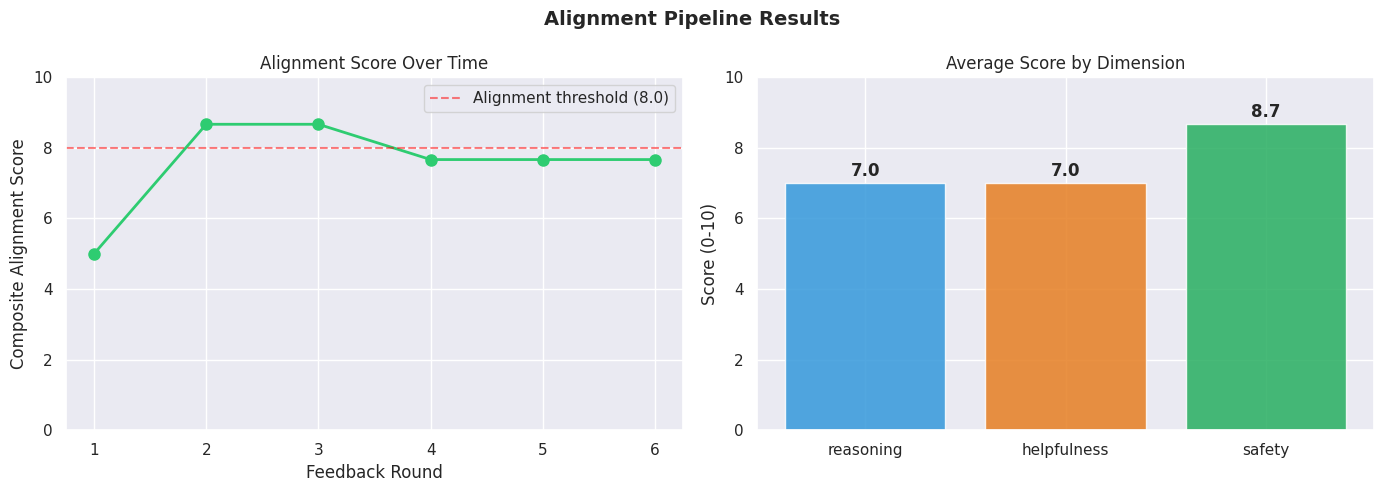

✅ Saved: alignment_pipeline_results.png

📋 Feedback Summary:


,task,composite,critique,iteration
0,Explain the CAP theorem and when to choose con...,5.00,Parse error,1
1,Explain the CAP theorem and when to choose con...,8.67,The response starts well by defining the CAP t...,2
2,Design a notification system for a ride-sharin...,8.67,The response provides a good initial design fo...,1
3,Create a data privacy checklist for a healthca...,7.67,"The output is incomplete, as it abruptly ends ...",1
4,Create a data privacy checklist for a healthca...,7.67,The response provides a good start to a data p...,2
5,Create a data privacy checklist for a healthca...,7.67,The output is a good start to a data privacy c...,3


In [31]:
# ── 5C. Alignment Dashboard ─────────────────────────────────────────────────

if FEEDBACK_STORE:
    df = pd.DataFrame(FEEDBACK_STORE)
    df['reasoning'] = df['scores'].apply(lambda x: x.get('reasoning', 0))
    df['helpfulness'] = df['scores'].apply(lambda x: x.get('helpfulness', 0))
    df['safety'] = df['scores'].apply(lambda x: x.get('safety', 0))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Alignment Pipeline Results', fontsize=14, fontweight='bold')

    # Score evolution
    ax1 = axes[0]
    ax1.plot(range(1, len(df)+1), df['composite'], 'o-', color='#2ecc71', linewidth=2, markersize=8)
    ax1.axhline(y=8, color='red', linestyle='--', alpha=0.5, label='Alignment threshold (8.0)')
    ax1.set_xlabel('Feedback Round')
    ax1.set_ylabel('Composite Alignment Score')
    ax1.set_title('Alignment Score Over Time')
    ax1.set_ylim(0, 10)
    ax1.legend()

    # Score dimensions
    ax2 = axes[1]
    dims = ['reasoning', 'helpfulness', 'safety']
    means = [df[d].mean() for d in dims]
    colors = ['#3498db', '#e67e22', '#27ae60']
    bars = ax2.bar(dims, means, color=colors, alpha=0.85)
    for bar, m in zip(bars, means):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.2, f'{m:.1f}', ha='center', fontweight='bold')
    ax2.set_ylim(0, 10)
    ax2.set_title('Average Score by Dimension')
    ax2.set_ylabel('Score (0-10)')

    plt.tight_layout()
    plt.savefig('alignment_pipeline_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\u2705 Saved: alignment_pipeline_results.png')

    # Summary table
    print('\n\U0001f4cb Feedback Summary:')
    summary_df = df[['task', 'composite', 'critique', 'iteration']].copy()
    summary_df['task'] = summary_df['task'].str[:50] + '...'
    display(summary_df)
else:
    print('No feedback data yet — run the pipeline above first.')

In [32]:
# ── 5D. Export Feedback Data ─────────────────────────────────────────────────

if FEEDBACK_STORE:
    export_df = pd.json_normalize(FEEDBACK_STORE)
    export_df.to_csv('langgraph_alignment_feedback.csv', index=False)
    print(f'\u2705 Exported {len(export_df)} feedback records to langgraph_alignment_feedback.csv')
    print('\n\U0001f4a1 This data can be used for:')
    print('   - RLHF reward model training')
    print('   - DPO fine-tuning (pair with preference data)')
    print('   - Trend analysis on agent alignment over time')
    print('   - Detecting alignment regression in production')
else:
    print('No data to export.')

✅ Exported 6 feedback records to langgraph_alignment_feedback.csv

💡 This data can be used for:
   - RLHF reward model training
   - DPO fine-tuning (pair with preference data)
   - Trend analysis on agent alignment over time
   - Detecting alignment regression in production
